# Text Embeddings with OpenAI

This notebook demonstrates how to generate and use text embeddings with OpenAI's API for semantic search, similarity comparisons, and visualization.

In [1]:
# DEPENDENCY: pip install openai tiktoken pandas scikit-learn matplotlib --upgrade --quiet
# (packages should be pre-installed in venv before running this script)

# Introduction to Vector Embeddings

## Theory: What Are Embeddings?
- An embedding is a high‑dimensional vector that captures the semantic meaning of text.
- Similar pieces of text have vectors that are close together in vector space (cosine similarity, dot product).
- Common use cases: search, clustering, recommendation, anomaly detection, classification.

## Getting Started: Install & Import
Make sure you have the OpenAI and tiktoken packages installed.

In [ ]:
import os
from getpass import getpass
import matplotlib.pyplot as plt
import numpy as np
from openai import OpenAI
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import tiktoken

# API Key Setup - uses environment variable or prompts for input
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

# Client and Model Configuration
client = OpenAI()
EMBEDDING_MODEL = "text-embedding-3-small"

## 1. Generate an Embedding
Use `text-embedding-3-small` to turn text into a 1536‑dimensional vector.

In [ ]:
def get_embedding(text, model=EMBEDDING_MODEL):
    text_clean = text.replace('\n', ' ')
    resp = client.embeddings.create(input=[text_clean], model=model)
    return np.array(resp.data[0].embedding)

sample = 'The quick brown fox jumps over the lazy dog.'
emb = get_embedding(sample)
print(f'Vector length: {len(emb)}')
print('First 5 dims:', emb[:5])

## 2. Count Tokens Before Embedding
Use `tiktoken` to estimate input size and control cost.

In [5]:
def num_tokens_from_string(s: str, encoding_name: str = 'cl100k_base') -> int:
    enc = tiktoken.get_encoding(encoding_name)
    return len(enc.encode(s))

print('Sample token count:', num_tokens_from_string(sample))

Sample token count: 10


## 3. Dimensionality Reduction & Visualization
Project a few sentence embeddings down to 2D with PCA.

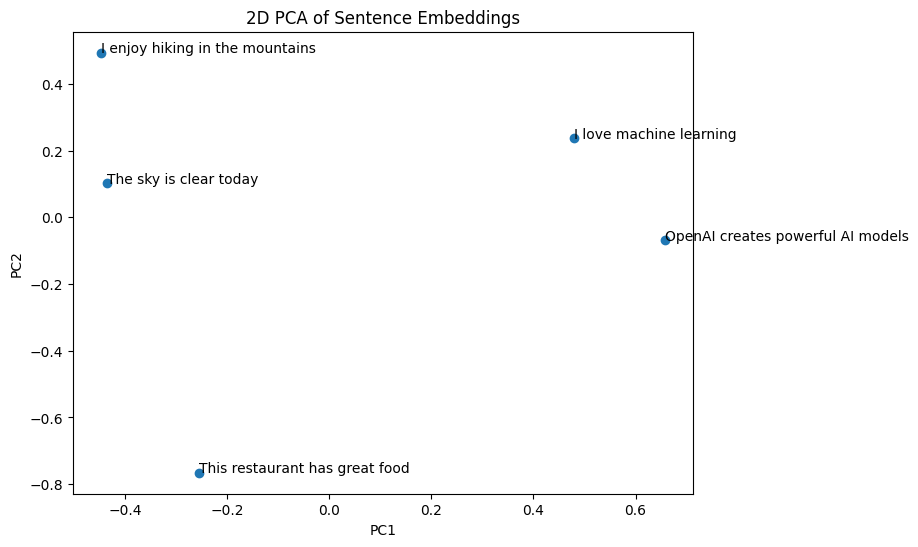

In [6]:
sentences = [
    'I love machine learning',
    'OpenAI creates powerful AI models',
    'The sky is clear today',
    'I enjoy hiking in the mountains',
    'This restaurant has great food'
]
vectors = np.vstack([get_embedding(s) for s in sentences])

pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(points[:,0], points[:,1])
for i, txt in enumerate(sentences):
    plt.annotate(txt, (points[i,0], points[i,1]))
plt.title('2D PCA of Sentence Embeddings')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### Interpreting the PCA Visualization

**What is PCA?** Principal Component Analysis (PCA) projects high-dimensional data (1536 dimensions for these embeddings) down to 2D for visualization. It finds the two directions that capture the most variance in the data.

**How to read this chart:**
- **Points close together** = semantically similar sentences
- **Points far apart** = semantically different sentences

**Important caveats:**
- PCA only preserves ~10-20% of the original information when reducing from 1536D to 2D
- Two points that appear close in 2D might actually be far apart in the original space
- For accurate similarity comparisons, always use cosine similarity on the full vectors (see below)

---

## Exercise for You
1. Pick 5 of your own short sentences.
2. Embed them using the `get_embedding` function.
3. Compute pairwise cosine similarities and identify the two most similar sentences.
4. (Bonus) Visualize them in 2D with PCA as above.

In [ ]:
# Exercise: Compute pairwise cosine similarities
similarity = cosine_similarity(vectors)
print("Pairwise cosine similarity matrix:")
print(similarity)

### Interpreting Cosine Similarity Values

**Cosine similarity** measures the angle between two vectors, ranging from 0 to 1 (for normalized embeddings):

| Score Range | Interpretation | Example Use Case |
|-------------|----------------|------------------|
| **0.9 - 1.0** | Nearly identical meaning | Duplicate detection |
| **0.7 - 0.9** | Strongly related | Semantic search matches |
| **0.5 - 0.7** | Moderately related | Topic clustering |
| **0.3 - 0.5** | Weakly related | Broad categorization |
| **0.0 - 0.3** | Unrelated | Different topics |

**Practical thresholds:**
- **Semantic search**: Use threshold of **0.7+** for high-quality matches
- **Duplicate detection**: Use threshold of **0.9+**
- **Clustering**: Values around **0.5+** indicate moderate similarity

**Reading the matrix:** The diagonal shows 1.0 (each sentence compared to itself). Off-diagonal values show pairwise similarities between different sentences.

In [ ]:
# Compare two specific sentences
similarity_0_1 = cosine_similarity(vectors[0].reshape(1, -1), vectors[1].reshape(1, -1))
print(f"Similarity between sentence 0 and 1: {similarity_0_1[0][0]:.4f}")